<a href="https://colab.research.google.com/github/lidiyashainy06/lidiya-codeboosters-2026/blob/main/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [14]:
print ("all libraries imported successfully !")
print(f"pandas version : {pd.__version__}")
print(f"sqlite3 version : {sqlite3.version}")

all libraries imported successfully !
pandas version : 2.2.2
sqlite3 version : 2.6.0


In [16]:
#load the dataset
df = pd.read_csv('student_performance.csv')
print(f"dataset loaded: {df.shape[0]} students,{df.shape[1]}columns")
print(f"columns : {df.columns.tolist()}")
print("\nfirst 3 rows: ")
df.head(3)

dataset loaded: 30 students,13columns
columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

first 3 rows: 


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [17]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index = False
)
cursor.execute("SELECT COUNT(*)FROM STUDENTS")
count = cursor.fetchone()[0]
print(f"database 'college.db'  created successfully! ")
print (f"table 'students' has {count} rows ")

database 'college.db'  created successfully! 
table 'students' has 30 rows 


In [18]:
#STEP 5: Helper functions to run SQL Queries
def run_query(sql,description="student"):
  """
  Runs a SQL Query and returns as a Pandas DataFrame

  Parameters:
  -----------
  sql         : str  - The SQL Query string to execute
  description : str  - A label to print above the results

  Returns:
  --------
  Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"{'='*55}")

  result = pd.read_sql_query(sql,conn)

  print(result.to_string(index=False))
  return result

print("Helper function 'run query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run query' defined successfully!
Usage: run_query(sql_string, description_label)


In [19]:
query1 =  """
    SELECT student_id, name,department, math_score, attendance_percentage
    FROM students
    LIMIT 10
"""
result1 = run_query(query1, "Query 1 : First 10 students (SELECT + LIMIT )")


 Query 1 : First 10 students (SELECT + LIMIT )
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [20]:
query2 = """
SELECT name, department,math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
result1 = run_query(query2, "Query 2 : Top 5 students by Math Score")


 Query 2 : Top 5 students by Math Score
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [21]:
query3 = """
  SELECT name, math_score, science_score, programming_score, attendance_percentage
   FROM students
    WHERE department = 'Computer Science'
   ORDER BY programming_score DESC

"""
result3 = run_query(query3, "Query 3 : Students from Computer Science")


 Query 3 : Students from Computer Science
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79       

In [22]:
query4 = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 90
AND department !='civil'
ORDER BY attendance_percentage DESC
"""
result4 = run_query(query4, "Query 4 : Students with attendance above 90%")


 Query 4 : Students with attendance above 90%
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [23]:
query5 = """
        SELECT name,department,attendance_percentage
        FROM students WHERE department !='Mechanical'
        AND attendance_percentage>93
        LIMIT(3)
  """
result5 = run_query(query5, "Query5: High Attendance (>93%) Excluding Mechanical Dept")



 Query5: High Attendance (>93%) Excluding Mechanical Dept
          name       department  attendance_percentage
   Divya Singh Computer Science                     96
    Ananya Das Computer Science                     98
Swati Kulkarni Computer Science                     94


In [24]:
query6=run_query("SELECT DISTINCT name FROM students")




query6= run_query("SELECT name FROM students WHERE name BETWEEN 'A' and 'F'")



 student
          name
  Aarav Sharma
   Priya Patel
   Rohit Verma
   Sneha Reddy
    Arjun Nair
   Meera Joshi
   Kiran Kumar
   Divya Singh
  Rahul Mishra
    Ananya Das
   Vikram Iyer
   Pooja Gupta
    Suresh Rao
 Kavya Nambiar
   Ajay Tiwari
  Ritu Agarwal
  Manoj Pandey
Swati Kulkarni
Deepak Chauhan
  Nisha Kapoor
 Harish Pillai
   Tanvi Mehta
  Sanjay Dubey
 Preeti Saxena
     Amit Bose
    Rekha Nair
 Gaurav Shukla
 Sunita Pillai
    Nitin Jain
Akanksha Yadav

 student
          name
  Aarav Sharma
    Arjun Nair
   Divya Singh
    Ananya Das
   Ajay Tiwari
Deepak Chauhan
     Amit Bose
Akanksha Yadav


In [29]:
query7 = """
   SELECT name
  FROM students
WHERE name BETWEEN 'A' AND 'F'
 ORDER BY name
result=run_query(query7, "Query 7: BETWEEN")


 Query 7: BETWEEN
          name
  Aarav Sharma
   Ajay Tiwari
Akanksha Yadav
     Amit Bose
    Ananya Das
    Arjun Nair
Deepak Chauhan
   Divya Singh


In [30]:
query8 = "SELECT department, ROUND(AVG(math_score), 2) AS avg_math FROM students GROUP BY department HAVING avg_math>70"
result8 = run_query(query8, "Query 8: Departments with Average Math Score > 70")


 Query 8: Departments with Average Math Score > 70
      department  avg_math
Computer Science     85.62
     Electronics     71.00
      Mechanical     71.00


In [31]:
query9 = """
          SELECT gender,
          COUNT(*) AS num_students,
          ROUND(AVG(math_score), 2) AS avg_math,
          ROUND(AVG(programming_score), 2) AS avg_programming,
          ROUND(AVG(attendance_percentage), 2) AS attendance_avg
          FROM students
          GROUP BY gender
          """
result9=run_query(query9,"GENDER ANALYSIS")


 GENDER ANALYSIS
gender  num_students  avg_math  avg_programming  attendance_avg
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


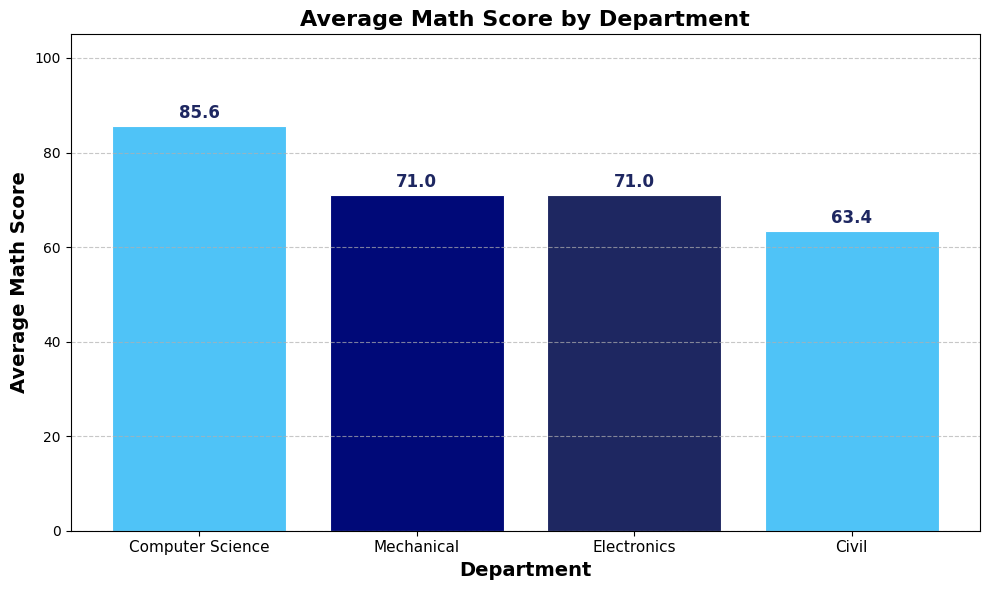

In [26]:
#Step 1 : Get data using SQL

chart1_sql = """
     SELECT department,ROUND(AVG(math_score),2) AS avg_score
     FROM students
     GROUP BY department
     ORDER BY avg_score DESC
"""

chart1_data = pd.read_sql_query(chart1_sql,conn)

#Step 2: Create the bar chart
fig, ax = plt.subplots(figsize=(10,6))
bar_colors = ['#4FC3F7','#000978','#1E2761'] # Added a third color and removed empty string

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_score'], # Corrected column name to avg_score
    color=bar_colors, # Corrected comma placement
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width()/2,
      height + 0.8, # Adjusted text position slightly above the bar
      f'{height:.1f}',
      ha='center',va='bottom',
      fontsize=12, fontweight='bold',
      color='#1E2761'
  )

ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold')
ax.set_xlabel('Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Math Score', fontsize=14, fontweight='bold')
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11) # Corrected to tick_params
ax.grid(axis ='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

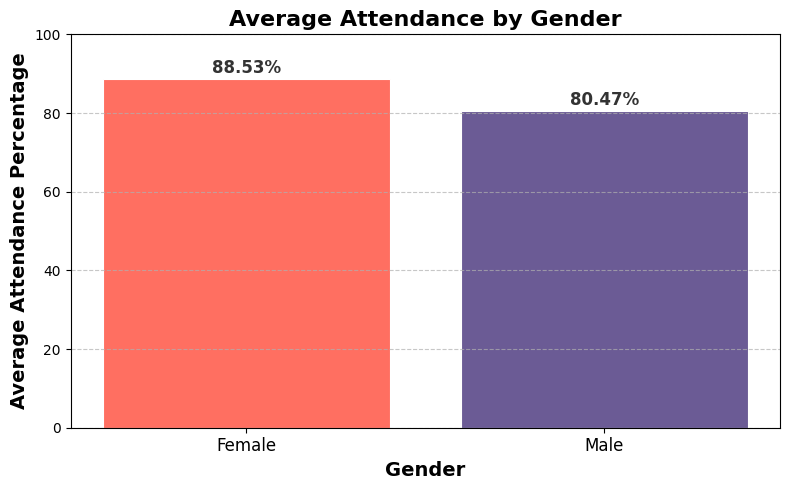

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

chart2_sql = """
     SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_attendance
     FROM students
     GROUP BY gender
"""

chart2_data = pd.read_sql_query(chart2_sql,conn)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    chart2_data['gender'],
    chart2_data['avg_attendance'],
    color=['#FF6F61', '#6B5B95'], # Custom colors for gender
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5, # Position text slightly above the bar
        f'{height:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#333333'
    )

ax.set_title('Average Attendance by Gender', fontsize=16, fontweight='bold')
ax.set_xlabel('Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Attendance Percentage', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100) # Attendance is a percentage, so 0-100 is appropriate
ax.tick_params(axis='x', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

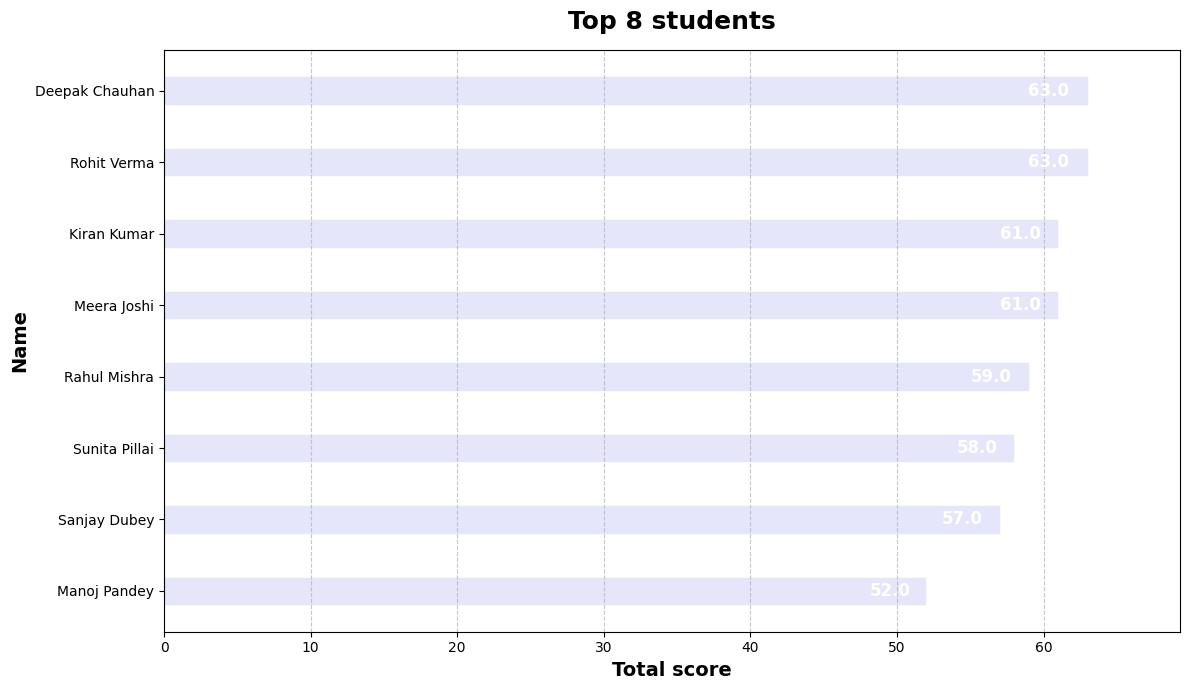

In [32]:
chart1_sql = "SELECT name, (math_score + english_score+ science_score + programming_score)/4 AS total_score FROM students ORDER BY total_score LIMIT(8)"
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax= plt.subplots(figsize=(12, 7)) # Increased figure size slightly

# Dynamic color assignment using a different colormap for bright colors
cmap = plt.cm.get_cmap('tab10') # Using 'tab10' colormap for bright and distinct colors
num_students = 8
# colors = [cmap(i) for i in range(8)] # Select colors directly from the colormap

bars=ax.barh(chart1_data['name'], chart1_data['total_score'], color='lavender', edgecolor='white', linewidth=0.4, height=0.4) # Changed to barh, height instead of width

for bar in bars:
  width = bar.get_width()
  ax.text(
      width * 0.98, # Adjusted x position to be near the end of the bar
      bar.get_y() + bar.get_height()/2, # Adjusted y position for horizontal bars
      f'{width:.1f}',
      ha='right', va='center', # Adjusted alignment for horizontal bars
      fontsize=12, fontweight='bold',
      color='white' # Changed text color to white
  )

ax.set_title('Top 8 students', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Name', fontsize=14, fontweight='bold') # Swapped labels
ax.set_xlabel('Total score', fontsize=14, fontweight='bold') # Swapped labels
ax.set_xlim(0, chart1_data['total_score'].max() * 1.1) # Changed to xlim
ax.grid(axis='x', linestyle='--', alpha=0.7) # Changed grid axis to x

plt.yticks(rotation=0, ha='right') # Changed to yticks, no rotation needed for horizontal labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('top8_students.png', dpi=300) # Save the figure
plt.show()

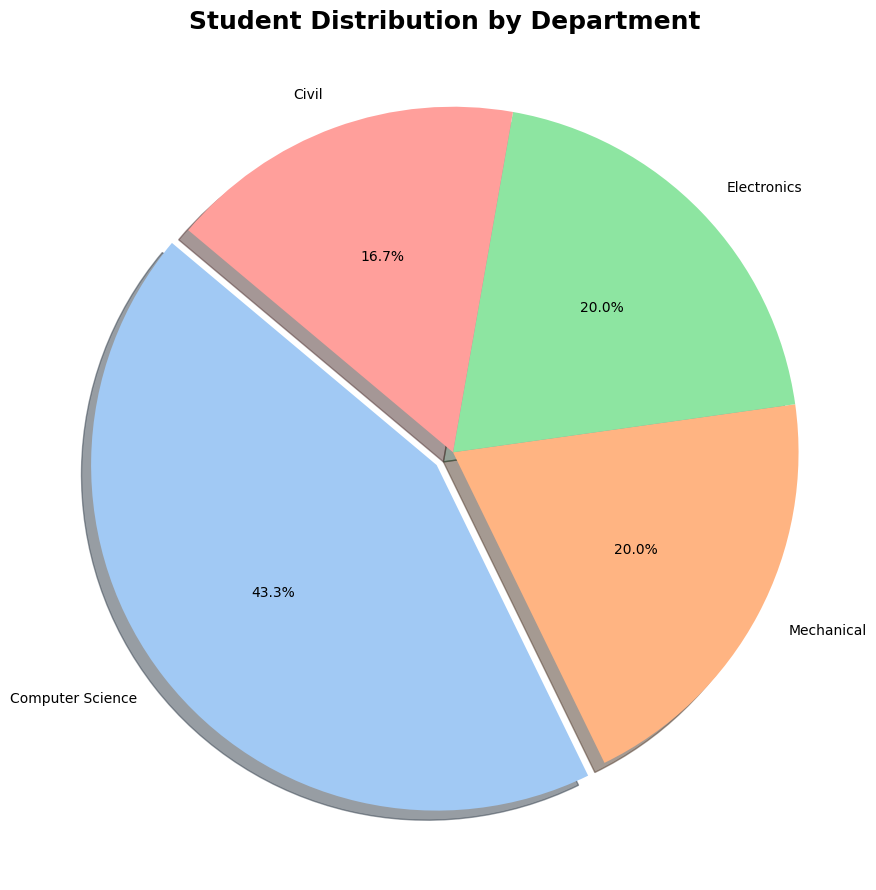

In [33]:
# Student Distribution by department(PIE CHART)

import matplotlib.pyplot as plt
import seaborn as sns

chart4_sql = """
    SELECT department, COUNT(*) AS num_students
    FROM students
    GROUP BY department
    ORDER BY num_students DESC
"""

chart4_data = pd.read_sql_query(chart4_sql,conn)

labels = chart4_data['department']
sizes = chart4_data['num_students'].tolist()
explode = [0.06] + [0] * (len(labels) - 1) # Explode the first slice for emphasis

colors = sns.color_palette('pastel')[0:len(labels)] # Define a color palette

fig, ax = plt.subplots(figsize=(9,9))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%', # Format for displaying percentages
    shadow=True,
    startangle=140
)

ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Student Distribution by Department', fontsize=18, fontweight='bold')

# Optional: add percentage value to the legend for clarity if labels are long
# plt.legend(wedges, [f'{l} - {s:.1f}%' for l, s in zip(labels, chart4_data['num_students'] / chart4_data['num_students'].sum() * 100)],
#            title="Departments",
#            loc="center left",
#            bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()